In [37]:
import os
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import DataLoader,random_split

from Tools.model_tools import*
from Tools.data_utils import SimulationData,generate_input_filename
from Encoder import*

Caricamento dei dati di simulazione da cui allenare il Decoder:

In [38]:
tau = 3
embedding_dim = 30
r = 20
alpha = 10
beta = 0

simulation_name= generate_input_filename(tau, embedding_dim, r, alpha, beta)
print(simulation_name)

# Carica i dati di simulazione
simulation = SimulationData.load_from_params(
    tau=tau, embedding_dim=embedding_dim, alpha=alpha, beta=beta, r=r, input_path="Simulation data"
)

delay3dim30,20_noise10,0


### Caricamento della configurazione Encoder precedentemente allenato a ricostruire $y_1(t)$:
Bisogna assicurarsi che l'encoder caricato abbia la stessa dimensione dello spazio latente del decoder che si vuole allenare

In [39]:
# Percorso del database
encoder_database_path = "encoderDatabase.json"
# Carica tutte le configurazioni disponibili
all_configs = load_configs(encoder_database_path)

encoder_name = "30-20_Noise10,0"
decoder_name = "30-20_Noise10,0-2"
encoder_config = get_model_config_by_name(encoder_database_path, encoder_name)
print(encoder_config)


{'layer_dims': [20, 15, 10, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.01, 'kl_annealing_epochs': 250, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay3dim30,20_noise10,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.02, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 10, 'min_lr': 1e-09, 'base_lr': 0.0001, 'max_lr': 0.01, 'step_size_up': 200, 'T_max': 100, 'T_0': 10, 'T_mult': 2, 'eta_min': 1e-08}}}


### Configurazione del Decoder:
Si scelgono i parametri per il training del solo decoder. L'encoder è già stato allenato per ricostruire il segnale di input, quindi lo spazio latente è stato preliminarmente regolarizzato. Per il training si utilizzerà solamente una loss di ricostruzione, quindi i parametri di KL vengono tagliati fuori.
Creare una configurazione già esistente sovrascriverà la configurazione presente nel database dopo il training e anche eventuali pesi già salvati. 


In [40]:
decoder_database_path = "decoderDatabase.json"

#Parametri per configurare il decoder
output_dim = 2*r
input_dim = encoder_config["latent_dim"]

# Importanti per il training:
decoder_layers = [input_dim,20,output_dim]
gamma = 10.0

latent_dim = encoder_config["latent_dim"]
if latent_dim != decoder_layers[0]:
    decoder_layers.append(latent_dim)

# Se vuoi creare una nuova configurazione
decoder_config = {
    "decoder_layers": decoder_layers,
    "latent_dim": latent_dim,
    "early_stopping": {"patience": 10, "delta": -1}, # Early stopping -1 per disattivare
    "dataset": simulation_name,
    "batch_size": 32,
    "optimizer": "Adam",
    "learning_rate": 0.02,
    "gamma" : gamma, # Valore che pesa la loss di Z3
    "scheduler": {
        "type": "ReduceLROnPlateau", 
        "params": {

            # Parametri per ReduceLROnPlateau
            "mode": "min",      # Monitora la perdita minima
            "factor": 0.5,      # Fattore di riduzione (LR = LR * factor)
            "patience": 10,     # Numero di epoche senza miglioramenti prima di ridurre LR
            "min_lr": 1e-09 ,  # Limite inferiore per il LR

            # Parametri per CyclicLR
            "base_lr": 0.0001,  # Minimo LR per CyclicLR
            "max_lr": 0.01,     # Massimo LR per CyclicLR
            "step_size_up": 200,  # Numero di step per aumentare il LR (solo per CyclicLR)

            # Parametri per CosineAnnealingLR
            "T_max": 100,       # Numero di step fino al minimo (solo per CosineAnnealingLR)

            # Parametri per CosineAnnealingWarmRestarts
            "T_0": 10,          # Numero di step per il primo ciclo (solo per CosineAnnealingWarmRestarts)
            "T_mult": 2,        # Fattore moltiplicativo per il ciclo successivo (solo per CosineAnnealingWarmRestarts)
            "eta_min": 0.00000001,  # Valore minimo per CosineAnnealingLR e CosineAnnealingWarmRestarts
        }
    },
    "Encoder": encoder_name # Encoder usato per allenare il decoder
}

epochs = 300

print(all_configs)

{'Model_1': {'layer_dims': [20, 15, 10, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.01, 'kl_annealing_epochs': 250, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay3dim100,20_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.02, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 10, 'min_lr': 1e-09, 'base_lr': 0.0001, 'max_lr': 0.01, 'step_size_up': 200, 'T_max': 100, 'T_0': 10, 'T_mult': 2, 'eta_min': 1e-08}}}, 'NoLeg': {'layer_dims': [20, 15, 10, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.01, 'kl_annealing_epochs': 250, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay3dim20,20_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.02, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 10, 'min_lr': 1e-09, 'base_l

Qua si creano i Dataset e i DataLoader per la ricostruzione di $y_2(t)$. Si usa la classe EmbeddedDatasetforDecoder in cui i target sono aggiustati per differenziare il training da quello del solo Encoder

In [41]:
# Seleziona le matrici di Hankel da SimulationData
y1_reduced_data = simulation.projected_H1
y2_1_reduced_data = simulation.projected_H2_1
y2_2_reduced_data = simulation.projected_H2_2

if y1_reduced_data is None or y2_1_reduced_data is None or y2_2_reduced_data is None:
    raise ValueError("Uno o più embedding non sono stati generati correttamente!")



In [42]:
# Crea il dataset
embedded_dataset = EmbeddedDatasetforDecoder(y1_reduced_data, y2_1_reduced_data, y2_2_reduced_data)

print("y1 Matrix shape:", y1_reduced_data.shape)  # Deve essere (n_samples, embedding_dim)
print(f"y2_1 Matrix shape: {y2_1_reduced_data.shape}")
print(f"y2_2 Matrix shape: {y2_2_reduced_data.shape}")

# Suddivisione del dataset
total_size = len(embedded_dataset)
train_size = int(0.60 * total_size)  # 60% per il training
val_size = total_size - train_size   # 40% per la validazione

# Suddivisione del dataset senza random split
train_data = torch.utils.data.Subset(embedded_dataset, range(train_size))
val_data = torch.utils.data.Subset(embedded_dataset, range(train_size, total_size))

# Stampa delle dimensioni
print(f"Dimensione del dataset: {total_size}")

# Prepara il DataLoader
batch_size = decoder_config["batch_size"]
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

# Debug del batch
for batch in train_loader:
    inputs, targets = batch  # Decomponi input e target
    inputs = inputs.float()
    targets = targets.float()
    print("Shape of input:", inputs.shape) # Batch size x r (dimensione del singolo sample di y1)
    print("Shape of target:", targets.shape) # Batch size x 2*r (dimensione del singolo sample di y2)

    z1_target = targets[:, :r]
    z3_target = targets[:, r:]

    print("Shape of z1_target:", z1_target.shape)
    print("Shape of z3_target:", z3_target.shape)

    break

y1 Matrix shape: (20, 9913)
y2_1 Matrix shape: (20, 9913)
y2_2 Matrix shape: (20, 9913)
Dimensione del dataset: 9913
Shape of input: torch.Size([32, 20])
Shape of target: torch.Size([32, 40])
Shape of z1_target: torch.Size([32, 20])
Shape of z3_target: torch.Size([32, 20])


In base all'encoder scelto all'inizio, di cui si sono caricati i parametri di configurazione, ora si caricano i pesi e i checkpoint del modello precedentemente allenato e si crea un'istanza di VAE unendo l'encoder allenato a un decoder da allenare.

In [43]:
#Caricamento del modello preallenato dell'encoder
encoder_model_path = "Encoder Models"
encoder_path = os.path.join(encoder_model_path, encoder_name + ".pth")

encoder, encoder_checkpoint = load_encoder(encoder_path, Encoder)

# Congela i parametri dell'encoder per impedire l'allenamento
for param in encoder.parameters():
    param.requires_grad = False
# Stampa i nomi e lo stato di requires_grad per i parametri dell'encoder
print("Parametri dell'encoder:")
for name, param in encoder.named_parameters():
    print(f"{name}: requires_grad={param.requires_grad}")


Encoder and training info loaded from Encoder Models/30-20_Noise10,0.pth
Parametri dell'encoder:
encoder.0.weight: requires_grad=False
encoder.0.bias: requires_grad=False
encoder.2.weight: requires_grad=False
encoder.2.bias: requires_grad=False
fc_mu.weight: requires_grad=False
fc_mu.bias: requires_grad=False
fc_log_var.weight: requires_grad=False
fc_log_var.bias: requires_grad=False


### Training del VAE per la ricostruzione di $y_2(t)$ :
Si chiama il ciclo di allenamento per il VAE in cui i gradienti per l'encoder e lo spazio latente sono disabilitati. Lo spazio latente è già stato regolarizzato quindi come loss verrà utilizzata solo una loss di ricostruzione (MSE loss).

Epoch [1/300], Training Loss: 0.001603, lr = 0.02
Z1 Loss: 0.000288, Z3 Loss: 0.001315
Epoch [2/300], Training Loss: 0.000565, lr = 0.02
Z1 Loss: 0.000177, Z3 Loss: 0.000388
Epoch [3/300], Training Loss: 0.000517, lr = 0.02
Z1 Loss: 0.000166, Z3 Loss: 0.000351
Epoch [4/300], Training Loss: 0.000488, lr = 0.02
Z1 Loss: 0.000164, Z3 Loss: 0.000324
Epoch [5/300], Training Loss: 0.000473, lr = 0.02
Z1 Loss: 0.000160, Z3 Loss: 0.000312
Epoch [6/300], Training Loss: 0.000459, lr = 0.02
Z1 Loss: 0.000158, Z3 Loss: 0.000300
Epoch [7/300], Training Loss: 0.000451, lr = 0.02
Z1 Loss: 0.000159, Z3 Loss: 0.000292
Epoch [8/300], Training Loss: 0.000446, lr = 0.02
Z1 Loss: 0.000161, Z3 Loss: 0.000285
Epoch [9/300], Training Loss: 0.000448, lr = 0.02
Z1 Loss: 0.000158, Z3 Loss: 0.000290
Epoch [10/300], Training Loss: 0.000440, lr = 0.02
Z1 Loss: 0.000160, Z3 Loss: 0.000280
Epoch [11/300], Training Loss: 0.000438, lr = 0.02
Z1 Loss: 0.000158, Z3 Loss: 0.000280
Epoch [12/300], Training Loss: 0.000434, 

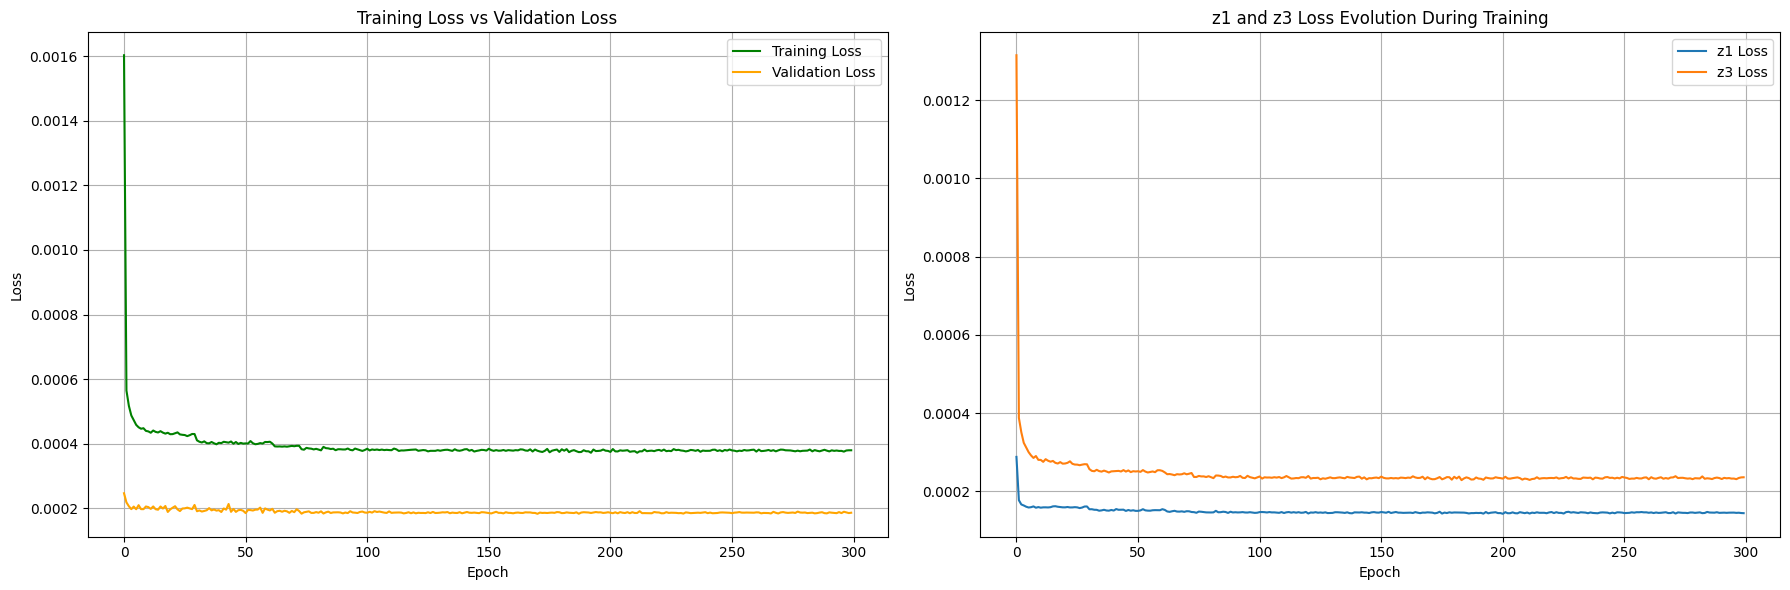

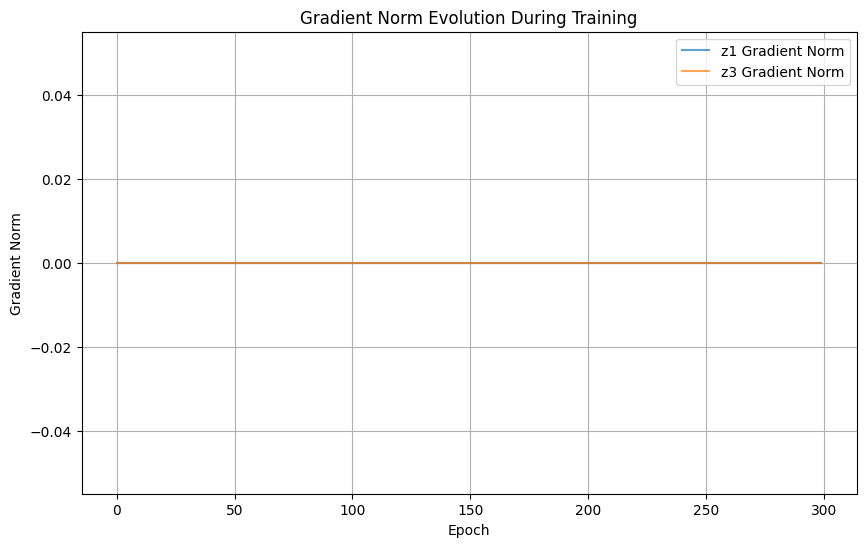

In [44]:
# Creazione del VAE con Decoder da allenare
decoder_layers_reversed = decoder_layers[::-1]
decoder = Decoder(decoder_layers_reversed)
vae_model = VAE(encoder,decoder)


# Configurazione Ottimizzatore e Scheduler

optimizer = optim.Adam(filter(lambda p: p.requires_grad, vae_model.parameters()), lr=decoder_config["learning_rate"])
scheduler_config = decoder_config.get("scheduler")
scheduler = get_scheduler(optimizer, scheduler_config)

# Allenamento del Decoder:
# Allenamento del modello
train_losses, val_losses, stopped_epoch, gradient_history, lr_evolution, z1_losses, z3_losses = reconstruct_y2fromy1(
    r = r, gamma=gamma, epochs=epochs,
    train_loader=train_loader,
    val_loader=val_loader,  # Aggiungi se hai un dataset di validazione
    model=vae_model,
    optimizer=optimizer,
    scheduler=scheduler,
    scheduler_config=scheduler_config,
    early_stopping_params=decoder_config["early_stopping"]
)

In [45]:
# Aggiungi la nuova configurazione al database (eventualmente sovrascrive)

add_config(decoder_config, decoder_name, decoder_database_path)

decoder_model_folder = "Decoder Models"
decoder_name += ".pth"


#Salva il modello allenato
save_decoder(decoder=decoder,decoder_layers=decoder_layers ,
            train_losses=train_losses, val_losses=val_losses,
            train_data=train_data, val_data=val_data, epoch=epochs, stopped_epoch=stopped_epoch, 
            gradient_history=gradient_history, lr_evolution=lr_evolution, z1_losses=z1_losses, z3_losses=z3_losses,
            output_folder=decoder_model_folder, decoder_name = decoder_name)

Decoder and training info saved to Decoder Models/30-20_Noise10,0-2.pth
